## Algorithm Of Colorimetry

## Import Libraries

In [1]:
import colour
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

## Separación de Muestras

In [12]:

#Carga de los datos
input_filename = ('samples/test-UN-05-12-25/test-UN-05-12-25.csv')
data = pd.read_csv(input_filename, low_memory=False)

#Extraer las longitudes de onda 'Wavelength (nm)'
wavelengths = data.iloc[1:, 0]

#Extraer las reflectancias de cada muestra 'Reflectances (%R)' - a partir de la columna 5 (índice 4)
reflectances = data.iloc[1:, 9::2]

#Unir todo en un nuevo DataFrame
master_data = pd.concat([wavelengths, reflectances], axis=1)
num_samples = master_data.shape[1] - 1

#Asignamos los nombres al DataFrame
new_columns = ['Wavelength (nm)'] + [f'Reflectance POS {i} (%R)' for i in range(num_samples)]
master_data.columns = new_columns

#Todo lo que sea texto (el reporte del final) se convertirá en NaN (Not a Number) y se elimina
master_data['Wavelength (nm)'] = pd.to_numeric(master_data['Wavelength (nm)'], errors='coerce')
master_data = master_data.dropna(subset=['Wavelength (nm)'])

#Guardar datos procesados
# Crear carpeta si no existe
os.makedirs("data-processed", exist_ok=True)
base_name = os.path.splitext(os.path.basename(input_filename))[0]
output_filename = f"data-processed/{base_name}_processed.csv"
master_data.to_csv(output_filename, index=False)
print(f'Archivo procesado guardado con nombre {output_filename}')


Archivo procesado guardado con nombre data-processed/test-UN-05-12-25_processed.csv


## View Data

## Raw Data

In [13]:
data.head()

,azul,Unnamed: 1,amarillo,Unnamed: 3,amarillo1,Unnamed: 5,POS0,Unnamed: 7,POS0.1,Unnamed: 9,...,Unnamed: 3247,POS1620,Unnamed: 3249,POS1621,Unnamed: 3251,POS1622,Unnamed: 3253,POS1623,Unnamed: 3255,Unnamed: 3256
0,Wavelength (nm),%R,Wavelength (nm),%R,Wavelength (nm),%R,Wavelength (nm),%R,Wavelength (nm),%R,...,%R,Wavelength (nm),%R,Wavelength (nm),%R,Wavelength (nm),%R,Wavelength (nm),%R,NaN
1,999.9968262,13.50374508,999.9968262,13.38597965,999.9968262,10.83688927,999.9968262,0.122915417,999.9968262,10.88006973,...,13.60817146,999.9968262,13.65930748,999.9968262,13.94774914,999.9968262,14.00308323,999.9968262,13.12256336,NaN
2,998.9901733,13.58608341,998.9901733,13.08951187,998.9901733,10.95640945,998.9901733,0.1453425735,998.9901733,10.83853531,...,13.46581745,998.9901733,13.4919672,998.9901733,13.82991695,998.9901733,13.95127583,998.9901733,13.12453461,NaN
3,998.0144043,13.35673904,998.0144043,13.11103535,998.0144043,11.03684711,998.0144043,-0.005023459438,998.0144043,10.90094852,...,13.37505531,998.0144043,13.71043968,998.0144043,13.89367771,998.0144043,13.73243046,998.0144043,13.05830193,NaN
4,997.0063477,13.51566792,997.0063477,13.59432507,997.0063477,10.78270626,997.0063477,0.3170843124,997.0063477,10.82398415,...,13.55656052,997.0063477,13.59833813,997.0063477,13.83490276,997.0063477,13.86307907,997.0063477,13.05166435,NaN


## Processing Data

In [14]:
master_data.head()

,Wavelength (nm),Reflectance POS 0 (%R),Reflectance POS 1 (%R),Reflectance POS 2 (%R),Reflectance POS 3 (%R),Reflectance POS 4 (%R),Reflectance POS 5 (%R),Reflectance POS 6 (%R),Reflectance POS 7 (%R),Reflectance POS 8 (%R),...,Reflectance POS 1614 (%R),Reflectance POS 1615 (%R),Reflectance POS 1616 (%R),Reflectance POS 1617 (%R),Reflectance POS 1618 (%R),Reflectance POS 1619 (%R),Reflectance POS 1620 (%R),Reflectance POS 1621 (%R),Reflectance POS 1622 (%R),Reflectance POS 1623 (%R)
1,999.996826,10.88006973,10.55554295,11.12090683,11.31832314,11.72433376,11.19561577,11.23832703,11.38045025,11.51302528,...,14.08677959,13.92284203,13.78280354,13.36514664,13.73365211,13.60817146,13.65930748,13.94774914,14.00308323,13.12256336
2,998.990173,10.83853531,10.66785145,11.2193222,11.25131321,11.61655045,11.16073895,11.36576557,11.34787083,11.27347946,...,13.86606407,13.63641357,13.79984188,13.68794155,13.68745136,13.46581745,13.4919672,13.82991695,13.95127583,13.12453461
3,998.014404,10.90094852,10.74832344,11.27271938,11.26995277,11.72376823,11.36640453,11.44081306,11.36143589,11.40830898,...,13.85192108,13.73760509,13.85492802,13.68766403,13.61350441,13.37505531,13.71043968,13.89367771,13.73243046,13.05830193
4,997.006348,10.82398415,10.60539341,10.87829685,11.32931709,11.56868267,11.45921993,11.4171505,11.31177807,11.32481003,...,13.88133144,13.72796249,13.77278996,13.53712273,13.86992455,13.55656052,13.59833813,13.83490276,13.86307907,13.05166435
5,995.997864,10.78483486,10.72645092,10.99993324,11.25600338,11.54915619,11.28520775,11.2916851,11.39393997,11.13711929,...,13.9078455,13.48077488,13.69780731,13.59582996,13.77955341,13.24187851,13.42874718,13.88430023,13.91635704,13.11176872


### Visualization of Spectrum

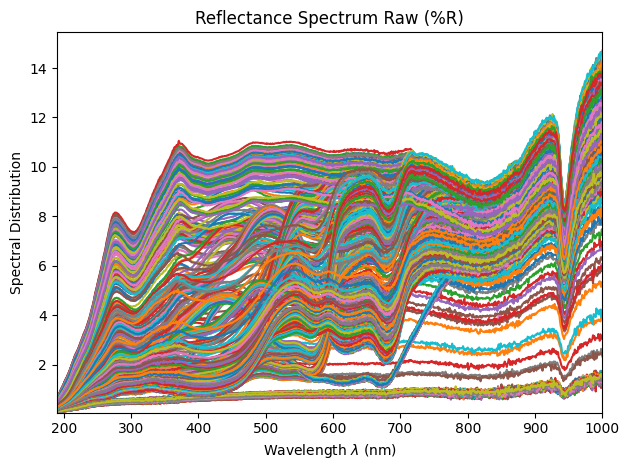

In [2]:
#Cargar datos
data_view = pd.read_csv('data-processed/test-celda-28-11-25_processed.csv')

#Organizar los datos de forma ascendente
data_view = data_view.set_index('Wavelength (nm)')
data_view = data_view.sort_index()

#Crear el objeto con datos crudos (0-100)
msds_raw = colour.MultiSpectralDistributions(data_view)

#Graficar los espectros crudos
fig, ax = colour.plotting.plot_multi_sds(
    msds_raw,
    title='Reflectance Spectrum Raw (%R)',
    legend=False
)
plt.show()

## Preprocessing Data to Color Parameters

### Negative Reflectance

In [16]:
#Cargar datos procesados
data_processed = pd.read_csv('data-processed/test-UN-05-12-25_processed.csv')

#Verificar si existen valores negativos
data_negatives = (data_processed< 0).stack()
data_negatives = data_negatives[data_negatives]

#Convertirlo a un Dataframe
data_negatives = data_negatives.reset_index()
data_negatives.columns = ['Row', 'Col', 'Is_negative']

#Obtener el valor negativo de Reflectancia
data_negatives['Reflectance (%R)'] = data_negatives.apply(
    lambda x: data_processed.loc[x['Row'], x['Col']], 
    axis=1
)

#Obtener el valor de la longitud de onda en donde hubo reflectancia negativa
wavelength_col = data_processed.columns[0]
data_negatives['Wavelength (nm)'] = data_negatives['Row'].apply(
    lambda r: data_processed.loc[r, wavelength_col]
)

print(data_negatives)

ValueError: Cannot set a DataFrame with multiple columns to the single column Reflectance (%R)

In [30]:
# Cargar datos
data_processed = pd.read_csv(
    'data-processed/test-celda-28-11-25_processed.csv',
    low_memory=False
)

# Separar columna de longitud de onda
wavelength_col = data_processed.columns[0]

# Solo evaluar reflectancias (excluir longitud de onda)
reflectance_data = data_processed.iloc[:, 1:]

# Detectar negativos
neg_mask = reflectance_data < 0

# Convertir a formato largo
data_negatives = neg_mask.stack()
data_negatives = data_negatives[data_negatives].reset_index()

data_negatives.columns = ['Row', 'Sample', 'Is_negative']

# Obtener valor real de reflectancia negativa
data_negatives['Reflectance (%R)'] = data_negatives.apply(
    lambda x: reflectance_data.loc[x['Row'], x['Sample']],
    axis=1
)

# Obtener longitud de onda correspondiente
data_negatives['Wavelength (nm)'] = data_negatives['Row'].map(
    data_processed[wavelength_col]
)

print(data_negatives)

ValueError: Cannot set a DataFrame with multiple columns to the single column Reflectance (%R)

In [17]:
# Detectar negativos directamente en formato largo
data_long = (
    reflectance_data
    .where(reflectance_data < 0)
    .stack()
    .reset_index()
)

data_long.columns = ['Row', 'Sample', 'Reflectance (%R)']

# Agregar longitud de onda
data_long['Wavelength (nm)'] = data_long['Row'].map(
    data_processed[wavelength_col]
)

print(data_long)

NameError: name 'reflectance_data' is not defined

## Debug DataFrame

In [2]:
data_processed = pd.read_csv('data-processed/test-UN-05-12-25_processed.csv')

In [3]:
data_processed.columns.is_unique
data_processed.columns[data_processed.columns.duplicated()]

Index([], dtype='object')

In [4]:
data_processed.isna().sum()

Wavelength (nm)              0
Reflectance POS 0 (%R)       0
Reflectance POS 1 (%R)       0
Reflectance POS 2 (%R)       0
Reflectance POS 3 (%R)       0
                            ..
Reflectance POS 1619 (%R)    0
Reflectance POS 1620 (%R)    0
Reflectance POS 1621 (%R)    0
Reflectance POS 1622 (%R)    0
Reflectance POS 1623 (%R)    0
Length: 1625, dtype: int64

In [4]:
print("Dimensiones:", data_processed.shape)
print("\nTipos de datos:")
print(data_processed.dtypes.value_counts())

Dimensiones: (811, 1683)

Tipos de datos:
float64    1683
Name: count, dtype: int64


In [9]:
nan_counts = data_processed.isna().sum()
print("\nColumnas con NaN:")
print(nan_counts[nan_counts > 0])


Columnas con NaN:
Series([], dtype: int64)


In [15]:
object_cols = data_processed.select_dtypes(include='object').columns
print("\nColumnas tipo object:")
print(object_cols)


Columnas tipo object:
Index([], dtype='object')


In [16]:
for col in object_cols:
    print(f"\nRevisando columna: {col}")
    print(data_processed[col].apply(type).value_counts())

In [17]:
suspicious = ["error", "ERROR", "NaN", "nan", " ", ""]
for val in suspicious:
    mask = data_processed.apply(lambda col: col.astype(str).str.contains(val, na=False))
    if mask.any().any():
        print(f"\nSe encontró '{val}' en:")
        print(mask.any()[mask.any()])


Se encontró '' en:
Wavelength (nm)              True
Reflectance POS 0 (%R)       True
Reflectance POS 1 (%R)       True
Reflectance POS 2 (%R)       True
Reflectance POS 3 (%R)       True
                             ... 
Reflectance POS 1677 (%R)    True
Reflectance POS 1678 (%R)    True
Reflectance POS 1679 (%R)    True
Reflectance POS 1680 (%R)    True
Reflectance POS 1681 (%R)    True
Length: 1683, dtype: bool


### Set negative reflectance values to zero and normalize

In [5]:
#Crear una copia de los datos procesados
data_normalized = data_processed.copy(deep=True)
data_normalized = data_normalized.set_index('Wavelength (nm)')
data_normalized = data_normalized.sort_index(ascending=True)

#Cambiar los valores negativos a 0
data_normalized[data_normalized < 0] = 0

#Normalizar los % de reflectancia entre 100 (Factor de 0 a 1)
data_normalized = data_normalized / 100.0

In [6]:
data_normalized

,Reflectance POS 0 (%R),Reflectance POS 1 (%R),Reflectance POS 2 (%R),Reflectance POS 3 (%R),Reflectance POS 4 (%R),Reflectance POS 5 (%R),Reflectance POS 6 (%R),Reflectance POS 7 (%R),Reflectance POS 8 (%R),Reflectance POS 9 (%R),...,Reflectance POS 1614 (%R),Reflectance POS 1615 (%R),Reflectance POS 1616 (%R),Reflectance POS 1617 (%R),Reflectance POS 1618 (%R),Reflectance POS 1619 (%R),Reflectance POS 1620 (%R),Reflectance POS 1621 (%R),Reflectance POS 1622 (%R),Reflectance POS 1623 (%R)
Wavelength (nm),,,,,,,,,,,,,,,,,,,,,
190.018662,0.002280,0.002466,0.002839,0.002613,0.001978,0.003204,0.003619,0.003443,0.004024,0.003913,...,0.005585,0.005471,0.005213,0.005039,0.005148,0.005225,0.004946,0.002566,0.002826,0.003090
191.009094,0.002545,0.002685,0.002953,0.002691,0.002267,0.003335,0.003827,0.003961,0.004431,0.004387,...,0.006405,0.006176,0.005819,0.005914,0.005732,0.006117,0.005614,0.002664,0.003232,0.003723
191.999466,0.002898,0.002884,0.003377,0.003120,0.002274,0.003853,0.004482,0.004341,0.004987,0.004812,...,0.006689,0.006814,0.006340,0.006336,0.006233,0.006293,0.006059,0.002958,0.003411,0.004030
192.989761,0.003098,0.003034,0.003536,0.003166,0.002373,0.004045,0.004774,0.004498,0.005363,0.005251,...,0.007215,0.007270,0.006842,0.006670,0.006797,0.006797,0.006527,0.003202,0.003687,0.004204
194.019592,0.003288,0.003228,0.003722,0.003375,0.002621,0.004336,0.005134,0.004864,0.005713,0.005621,...,0.007842,0.007825,0.007304,0.007200,0.007301,0.007347,0.006982,0.003451,0.004002,0.004513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995.997864,0.107848,0.107265,0.109999,0.112560,0.115492,0.112852,0.112917,0.113939,0.111371,0.110989,...,0.139078,0.134808,0.136978,0.135958,0.137796,0.132419,0.134287,0.138843,0.139164,0.131118
997.006348,0.108240,0.106054,0.108783,0.113293,0.115687,0.114592,0.114172,0.113118,0.113248,0.108307,...,0.138813,0.137280,0.137728,0.135371,0.138699,0.135566,0.135983,0.138349,0.138631,0.130517
998.014404,0.109009,0.107483,0.112727,0.112700,0.117238,0.113664,0.114408,0.113614,0.114083,0.111361,...,0.138519,0.137376,0.138549,0.136877,0.136135,0.133751,0.137104,0.138937,0.137324,0.130583


### Create MultiSpectralDistribution and XYZ Values

In [7]:
#Crear objeto
msds = colour.MultiSpectralDistributions(data_normalized)

#Verificamos la dimension y la forma de los espectros (Valor Max, Valor Min, Saltos)
print(msds.shape)
print(msds.domain[:5])

#Definimos nueva forma de nuestro espectro en el rango visible
shape = colour.SpectralShape(360, 750, 1)

#Interpolacion de los espectros para que los saltos sean de 1nm
msds = msds.align(shape)

#Cargar estandares de la CIE
cmfs = colour.MSDS_CMFS['CIE 1931 2 Degree Standard Observer']
illuminant = colour.SDS_ILLUMINANTS['D65']

#Calculo XYZ
XYZ = colour.msds_to_XYZ(msds, cmfs, illuminant)

#Visualizar valores XYZ calculados
print("Dimensión de XYZ:", XYZ.shape)
print("Valores XYZ:\n", XYZ)

(190.0186615, 999.9968262, 0.9630736999999954)
[ 190.0186615  191.0090942  191.9994659  192.9897614  194.0195923]
Dimensión de XYZ: (1624, 3)
Valores XYZ:
 [[  7.64624547   8.17544069   8.48836463]
 [  7.55345933   8.06498043   8.2598222 ]
 [  7.86064699   8.39142339   8.67368155]
 ..., 
 [ 10.06041921  10.73317796  11.34929563]
 [ 10.0388379   10.71297865  11.29755204]
 [  9.56996018  10.21811688  10.77175794]]


## Calculate CIELab (L* a* b*)

In [8]:
#Definir punto blanco para el iluminante D65
illuminant_xy = colour.CCS_ILLUMINANTS['CIE 1931 2 Degree Standard Observer']['D65']

#Usamos los valores XYZ para calcular CIELab
Lab = colour.XYZ_to_Lab(XYZ, illuminant=illuminant_xy)

#Visualizar valores Lab calculados
print('Valores CIELab calculados.')
print("Valores (L, a, b):\n", Lab)

Valores CIELab calculados.
Valores (L, a, b):
 [[ 217.68367823   -5.39327065    6.36225519]
 [ 216.62645109   -4.90525454    8.13072254]
 [ 219.72367352   -4.90841589    7.01449592]
 ..., 
 [ 239.87867857   -5.10475538    4.31645884]
 [ 239.71806078   -5.19800323    4.70444265]
 [ 235.71838954   -5.3105799     4.68305561]]


## Visualization of XYZ in sRGB

Muestras fuera de gamut sRGB: 1577 de 1624


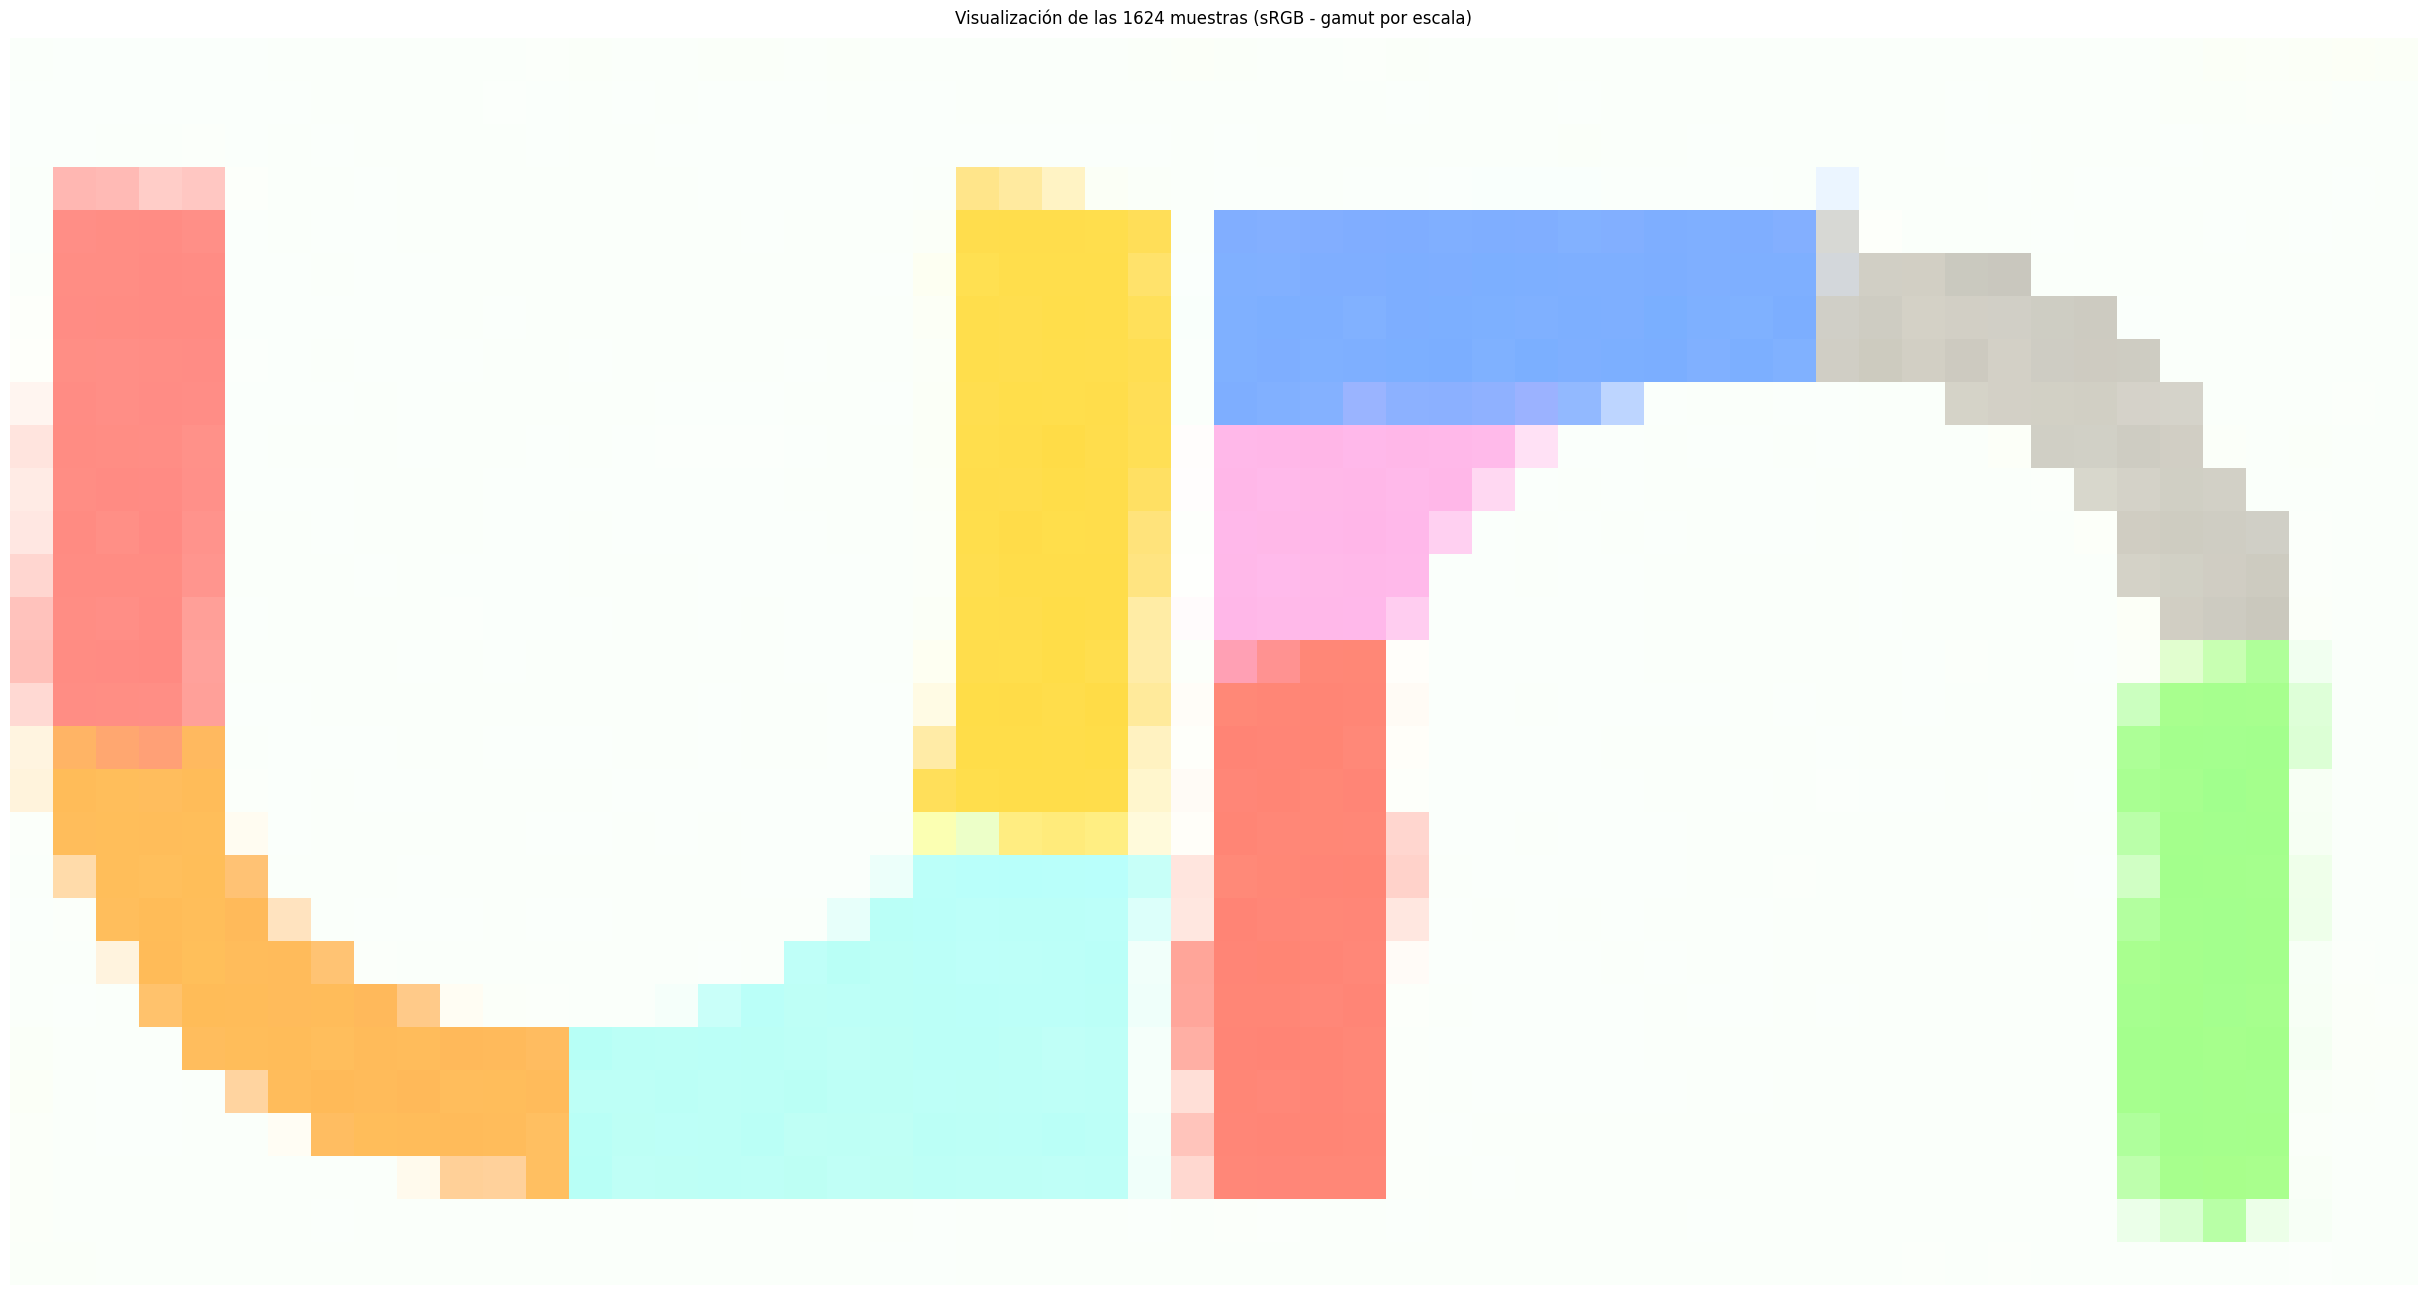

In [16]:

# Convertimos los tristimulos XYZ a sRGB
RGB = colour.XYZ_to_sRGB(XYZ, illuminant=illuminant_xy)

# ── Gamut mapping por escala (preserva tono, reduce saturación) ──────────────
RGB_mapped = np.clip(RGB, 0, None)
max_per_sample = RGB_mapped.max(axis=1, keepdims=True)
scale = np.where(max_per_sample > 1, max_per_sample, 1.0)
RGB_mapped = RGB_mapped / scale

n = RGB_mapped.shape[0]
cols = 56
rows = int(np.ceil(n / cols))

# Rellenar hasta completar la rejilla (fila por fila)
pad = rows * cols - n
if pad > 0:
    RGB_mapped = np.vstack([RGB_mapped, np.ones((pad, 3))])  # relleno blanco

# Reshape a imagen (rows, cols, 3) — fila por fila, sin rotación
img = RGB_mapped.reshape(rows, cols, 3)
img = np.fliplr(img)  # espejo horizontal

print(f"Muestras fuera de gamut sRGB: {(RGB.max(axis=1) > 1).sum()} de {n}")

fig, ax = plt.subplots(figsize=(cols * 0.45, rows * 0.45))
ax.imshow(img, aspect='equal', interpolation='nearest')
ax.set_title(f'Visualización de las {n} muestras (sRGB - gamut por escala)', pad=10)
ax.axis('off')
plt.tight_layout()
plt.show()


## Visualization of Lab in sRGB

Muestras fuera de gamut sRGB (desde Lab): 1577 de 1624


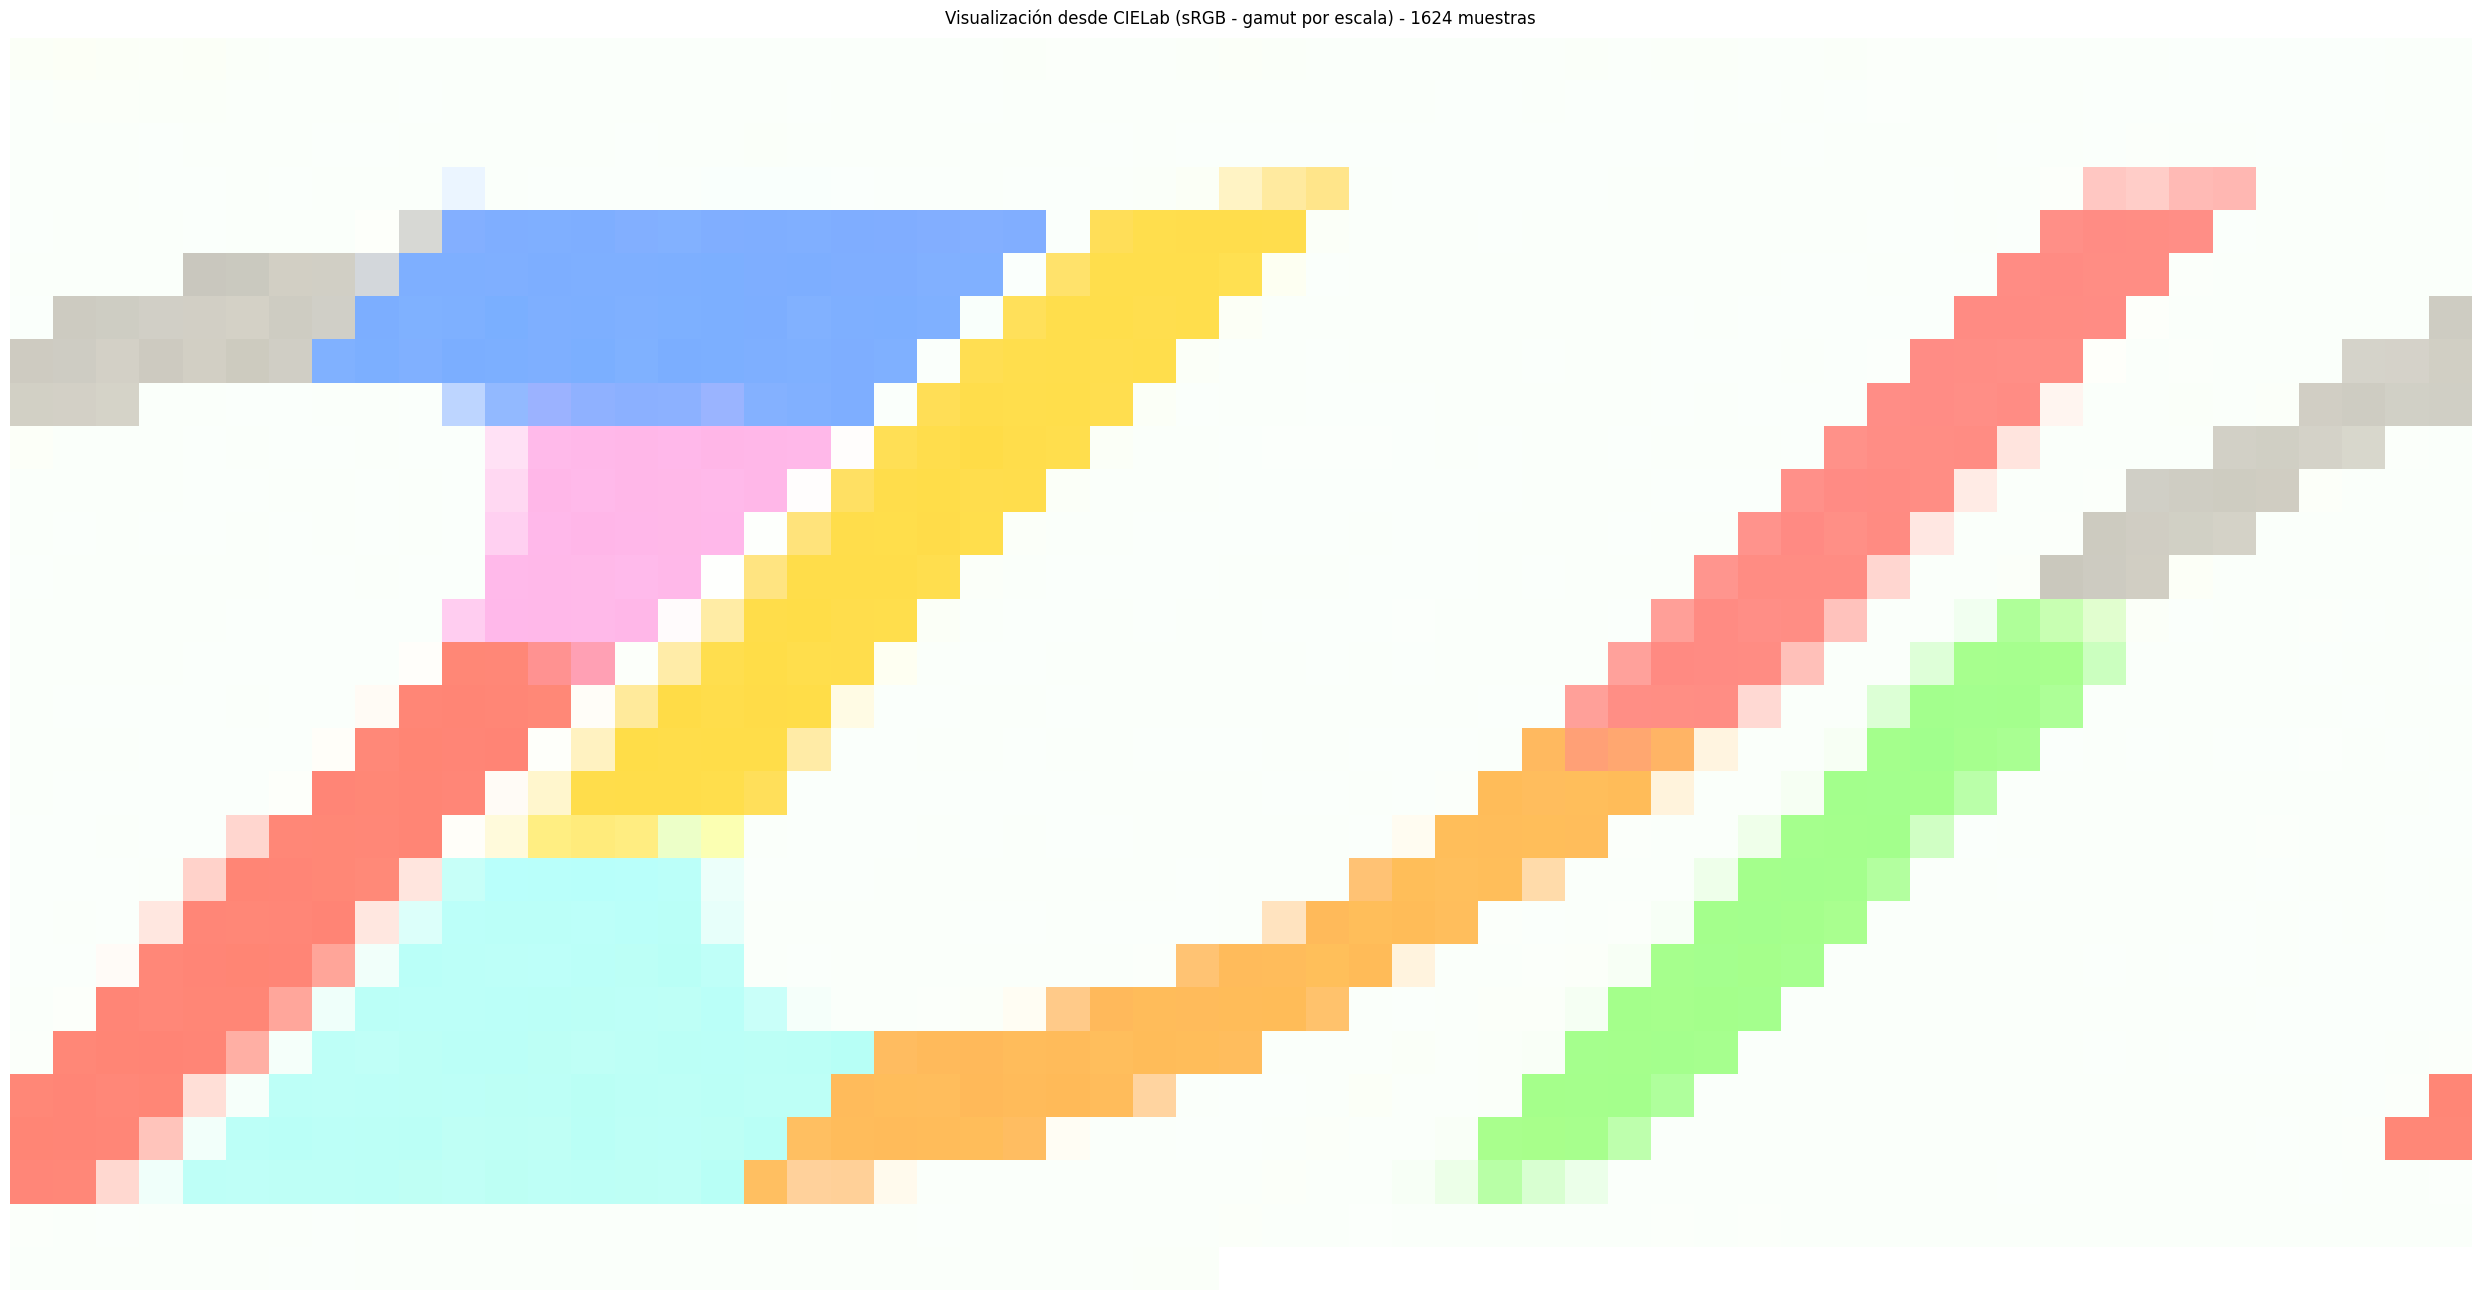

In [ ]:

# Lab -> XYZ -> sRGB con gamut mapping por escala
XYZ_from_Lab = colour.Lab_to_XYZ(Lab, illuminant=illuminant_xy)
RGB_from_Lab = colour.XYZ_to_sRGB(XYZ_from_Lab, illuminant=illuminant_xy)

RGB_from_Lab = np.clip(RGB_from_Lab, 0, None)
max_per_sample = RGB_from_Lab.max(axis=1, keepdims=True)
scale = np.where(max_per_sample > 1, max_per_sample, 1.0)
RGB_from_Lab_mapped = RGB_from_Lab / scale

n = RGB_from_Lab_mapped.shape[0]
cols = 56
rows = int(np.ceil(n / cols))

# Rellenar hasta completar la rejilla (fila por fila)
pad = rows * cols - n
if pad > 0:
    RGB_from_Lab_mapped = np.vstack([RGB_from_Lab_mapped, np.ones((pad, 3))])

# Reshape a imagen (rows, cols, 3) — fila por fila, sin rotación
img_lab = RGB_from_Lab_mapped.reshape(rows, cols, 3)


print(f"Muestras fuera de gamut sRGB (desde Lab): {(RGB_from_Lab.max(axis=1) > 1).sum()} de {n}")

fig, ax = plt.subplots(figsize=(cols * 0.45, rows * 0.45))
ax.imshow(img_lab, aspect='equal', interpolation='nearest')
ax.set_title(f'Visualización desde CIELab (sRGB - gamut por escala) - {n} muestras', pad=10)
ax.axis('off')
plt.tight_layout()
plt.show()
